### Grafik Türü Seçimi

Grafik seçimi rastgele değil, verinin türüne ve sormaya çalıştığın soruya göre değişir. 4 temel kategori var:

**1. Karşılaştırma (Comparison)**
- Soru: Hangi kategori daha iyi/kötü?
- Grafik: Bar Chart
- Örnek: Hangi ürün kategorisi en çok satıyor?

**2. Dağılım (Distribution)**
- Soru: Veri nasıl yayılmış, hangi değerler yaygın?
- Grafik: Histogram, Box Plot
- Örnek: Müşteri yaşları hangi aralıkta yoğunlaşıyor?

**3. İlişki (Relationship)**
- Soru: İki değişken birbirini nasıl etkiliyor?
- Grafik: Scatter Plot
- Örnek: Reklam harcaması arttıkça satış nasıl değişiyor?

**4. Zaman Serisi / Trend (Trend Over Time)**
- Soru: Bir şey zamanla nasıl değişiyor?
- Grafik: Line Chart
- Örnek: Aylık gelir son 1 yılda nasıl seyretti?

### Yaygın Hatalar
1. Pie Chart aşırı kullanımı — insan gözü açıları karşılaştırmakta kötü, 3'ten fazla dilim varsa bar chart daha nettir.
2. Y ekseninin sıfırdan başlamaması — bar chart'ta küçük farkları abartılı/yanıltıcı gösterir.
3. Çok fazla renk/kategori bir arada kullanmak — okunaksız hale getirir.
4. Yanlış grafik türü, yanlış mesaj verir — örneğin zaman serisini bar chart ile göstermek trendi gizler.

### Örnek

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


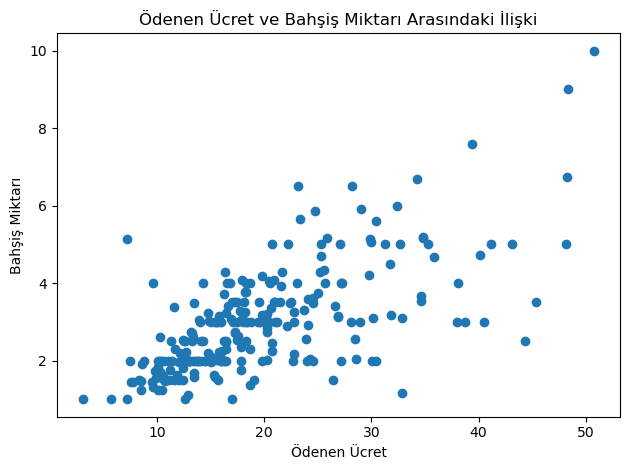

In [3]:
plt.scatter(x = df["total_bill"], y = df["tip"])
plt.xlabel("Ödenen Ücret")
plt.ylabel("Bahşiş Miktarı")
plt.title("Ödenen Ücret ve Bahşiş Miktarı Arasındaki İlişki")
plt.tight_layout()
plt.show()

Yukarıdaki örnekte iki veri arasındaki ilişkiyi gösteren ilişki grafiğini yani doğru bir grafik türü kullandık ancak aşağıda ise bu iki değişkeni çizgi grafiği gibi bir yanlış grafikle göstereceğiz neden bu grafik türü yanlış? Çünkü burada veri sıralı bir zamanı takip etmiyor. 

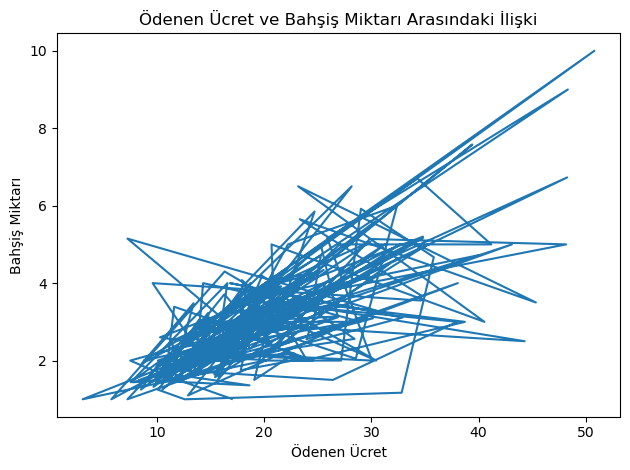

In [5]:
plt.plot(df["total_bill"],df["tip"])
plt.xlabel("Ödenen Ücret")
plt.ylabel("Bahşiş Miktarı")
plt.title("Ödenen Ücret ve Bahşiş Miktarı Arasındaki İlişki")
plt.tight_layout()
plt.show()

Yukarıdaki veri zamana göre bir artış azalış şeklinde hareket etmediği için böyle anlamsız bir sonuç ortaya çıkıyor.Örneğin, x ekseninde tarihler y ekseninde ödenen ücretler olsaydı ortaya anlamlı bir grafik ortaya çıkabilirdi. 

C:\Users\asus\AppData\Local\Temp\ipykernel_11684\4077213431.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gunluk_ortalama = df.groupby('day')['tip'].mean()


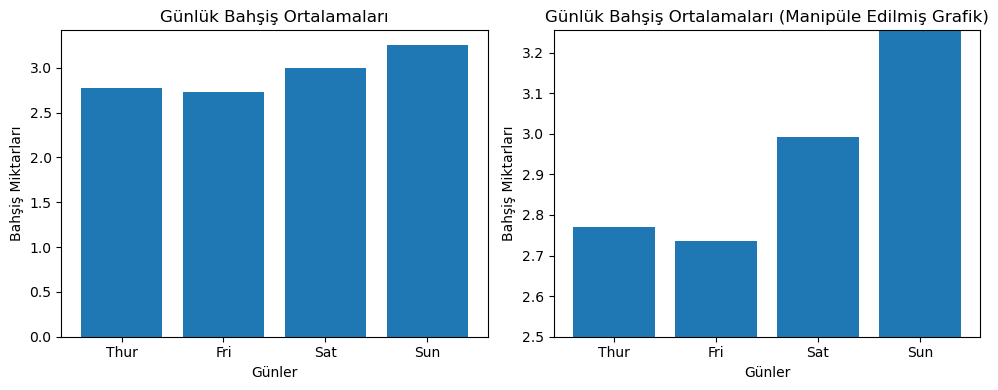

In [11]:
gunluk_ortalama = df.groupby('day')['tip'].mean()
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].bar(gunluk_ortalama.index, gunluk_ortalama.values)
ax[0].set_title("Günlük Bahşiş Ortalamaları")
ax[0].set_xlabel("Günler")
ax[0].set_ylabel("Bahşiş Miktarları")

ax[1].bar(gunluk_ortalama.index, gunluk_ortalama.values)
ax[1].set_title("Günlük Bahşiş Ortalamaları (Manipüle Edilmiş Grafik)")
ax[1].set_xlabel("Günler")
ax[1].set_ylabel("Bahşiş Miktarları")
ax[1].set_ylim(2.5, max(gunluk_ortalama.values))

plt.tight_layout()
plt.show()

### Y Ekseni Manipülasyonu Gözlemi
Aynı veri, iki farklı y ekseni aralığıyla gösterildiğinde çok farklı bir izlenim veriyor. Sol grafikte (y ekseni 0'dan başlıyor) günler arası fark makul görünürken, sağ grafikte (y ekseni 2.5'ten başlıyor) Sunday'in barı Thursday'e göre çok daha büyükmüş gibi görünüyor. Oysa gerçek fark sadece ~%18. Bu, dar y ekseni aralığının küçük farkları nasıl abartılı gösterebileceğinin somut bir göstergesidir.